# Noon UAE — Synthetic E-Commerce Dataset Generator

This notebook generates a **synthetic** 3-month order-level dataset (Apr 1 – Jun 30, 2026) styled after a UAE e-commerce marketplace like Noon.

> The data is entirely fabricated for demo/portfolio purposes (Streamlit dashboards, GitHub projects, etc.) — it is **not** real Noon data.

**Output:** `noon_uae_sales_data.csv` — ready to drop into a Streamlit app.

Run all cells top to bottom. Re-running with the same seed reproduces the same dataset.

## 1. Imports & configuration

In [1]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta

np.random.seed(42)

N = 6000  # number of orders to generate

start_date = datetime(2026, 4, 1)
end_date = datetime(2026, 6, 30)
date_range_days = (end_date - start_date).days

print(f"Generating {N} orders between {start_date.date()} and {end_date.date()}")

Generating 6000 orders between 2026-04-01 and 2026-06-30


## 2. Reference data — UAE cities, categories, brands, payment/device options

In [2]:
cities = ["Dubai", "Abu Dhabi", "Sharjah", "Ajman", "Ras Al Khaimah", "Fujairah", "Umm Al Quwain", "Al Ain"]
city_weights = [0.38, 0.22, 0.14, 0.07, 0.06, 0.04, 0.03, 0.06]

categories = {
    "Mobiles & Tablets": ["Samsung", "Apple", "Xiaomi", "Oppo", "Huawei"],
    "Electronics": ["Sony", "LG", "Samsung", "JBL", "Anker"],
    "Fashion": ["Noon Basics", "Zara Style", "H&M Style", "Levi's", "Local Label"],
    "Home & Kitchen": ["Tefal", "Philips", "Black+Decker", "IKEA Style", "Prestige"],
    "Beauty": ["L'Oreal", "Nivea", "Maybelline", "The Body Shop", "Dove"],
    "Grocery": ["Al Ain", "Lacnor", "Nestle", "Al Marai", "Barakat"],
    "Sports & Outdoors": ["Nike", "Adidas", "Puma", "Decathlon Style", "Under Armour"],
    "Toys & Baby": ["LEGO", "Fisher-Price", "Pampers", "Huggies", "Mattel"],
    "Books & Stationery": ["Penguin", "Oxford", "Faber-Castell", "Local Publisher", "Staedtler"],
    "Appliances": ["LG", "Samsung", "Bosch", "Panasonic", "Midea"],
}
cat_names = list(categories.keys())
cat_weights = [0.16, 0.14, 0.15, 0.10, 0.10, 0.08, 0.09, 0.06, 0.05, 0.07]

base_price_map = {
    "Mobiles & Tablets": (400, 4500),
    "Electronics": (80, 2500),
    "Fashion": (30, 450),
    "Home & Kitchen": (40, 900),
    "Beauty": (15, 350),
    "Grocery": (5, 150),
    "Sports & Outdoors": (30, 700),
    "Toys & Baby": (20, 500),
    "Books & Stationery": (10, 200),
    "Appliances": (150, 3500),
}

payment_methods = ["Cash on Delivery", "Credit/Debit Card", "Noon Pay Later", "Apple Pay"]
payment_weights = [0.42, 0.33, 0.15, 0.10]

device_types = ["Mobile App", "Mobile Web", "Desktop"]
device_weights = [0.68, 0.20, 0.12]

delivery_status_opts = ["Delivered", "In Transit", "Cancelled", "Returned"]
delivery_weights = [0.82, 0.06, 0.07, 0.05]

## 3. Generate order-level records

In [3]:
order_ids = [f"NOON-AE-{100000+i}" for i in range(N)]

order_dates = [
    start_date + timedelta(
        days=int(np.random.randint(0, date_range_days + 1)),
        seconds=int(np.random.randint(0, 86400)),
    )
    for _ in range(N)
]

customer_ids = [f"CUST-{np.random.randint(1, 2200):05d}" for _ in range(N)]
cust_cities = np.random.choice(cities, size=N, p=city_weights)
cust_categories = np.random.choice(cat_names, size=N, p=cat_weights)
brands = [np.random.choice(categories[c]) for c in cust_categories]

unit_prices = [round(np.random.uniform(*base_price_map[c]), 2) for c in cust_categories]
quantities = np.random.choice([1, 1, 1, 2, 2, 3, 4], size=N)
discounts = np.round(np.random.choice([0, 0, 5, 10, 15, 20, 25, 30, 40], size=N), 0)

df = pd.DataFrame({
    "order_id": order_ids,
    "order_date": order_dates,
    "customer_id": customer_ids,
    "city": cust_cities,
    "category": cust_categories,
    "brand": brands,
    "unit_price_aed": unit_prices,
    "quantity": quantities,
    "discount_percent": discounts,
})

df.head()

,order_id,order_date,customer_id,city,category,brand,unit_price_aed,quantity,discount_percent
0,NOON-AE-100000,2026-05-22 00:14:20,CUST-01621,Dubai,Home & Kitchen,Tefal,839.90,2,10
1,NOON-AE-100001,2026-04-15 21:20:20,CUST-01595,Dubai,Books & Stationery,Penguin,177.06,1,10
2,NOON-AE-100002,2026-06-22 10:19:54,CUST-00566,Ajman,Fashion,Local Label,378.02,4,20
3,NOON-AE-100003,2026-06-14 12:15:31,CUST-00704,Ajman,Mobiles & Tablets,Huawei,2812.07,2,5
4,NOON-AE-100004,2026-04-24 11:24:50,CUST-00858,Ras Al Khaimah,Grocery,Lacnor,19.73,2,20


## 4. Derived columns — revenue, payment, delivery, ratings, VIP flag

In [4]:
df["total_amount_aed"] = (
    df["unit_price_aed"] * df["quantity"] * (1 - df["discount_percent"] / 100)
).round(2)

df["payment_method"] = np.random.choice(payment_methods, size=N, p=payment_weights)
df["device_type"] = np.random.choice(device_types, size=N, p=device_weights)
df["delivery_status"] = np.random.choice(delivery_status_opts, size=N, p=delivery_weights)

df["delivery_days"] = np.where(
    df["delivery_status"] == "Delivered",
    np.random.randint(1, 6, size=N),
    np.nan,
)

df["is_noon_vip"] = np.random.choice([True, False], size=N, p=[0.28, 0.72])

df["customer_rating"] = np.where(
    df["delivery_status"] == "Delivered",
    np.random.choice([1, 2, 3, 4, 5], size=N, p=[0.03, 0.05, 0.12, 0.35, 0.45]),
    np.nan,
)

df = df.sort_values("order_date").reset_index(drop=True)
df["order_date"] = df["order_date"].dt.strftime("%Y-%m-%d %H:%M:%S")

df.head()

,order_id,order_date,customer_id,city,category,brand,unit_price_aed,quantity,discount_percent,total_amount_aed,payment_method,device_type,delivery_status,delivery_days,is_noon_vip,customer_rating
0,NOON-AE-100345,2026-04-01 00:06:44,CUST-00640,Abu Dhabi,Fashion,Noon Basics,188.61,1,0,188.61,Credit/Debit Card,Mobile Web,Delivered,1.0,True,5.0
1,NOON-AE-100563,2026-04-01 00:29:19,CUST-00067,Ras Al Khaimah,Fashion,Local Label,419.91,1,10,377.92,Cash on Delivery,Mobile App,Delivered,5.0,False,5.0
2,NOON-AE-100116,2026-04-01 00:30:02,CUST-01413,Ajman,Grocery,Barakat,111.64,2,30,156.30,Noon Pay Later,Mobile App,Delivered,2.0,False,5.0
3,NOON-AE-102171,2026-04-01 00:36:27,CUST-01297,Sharjah,Fashion,Local Label,253.23,1,30,177.26,Noon Pay Later,Desktop,Delivered,4.0,False,4.0
4,NOON-AE-103168,2026-04-01 00:45:16,CUST-00866,Dubai,Sports & Outdoors,Puma,582.75,1,30,407.92,Apple Pay,Mobile App,Delivered,2.0,False,4.0


## 5. Quick sanity checks

In [5]:
print("Shape:", df.shape)
print("\nColumn dtypes:\n", df.dtypes)
print("\nDelivery status split:\n", df["delivery_status"].value_counts())
print("\nTotal revenue (AED):", round(df["total_amount_aed"].sum(), 2))
print("\nNull counts:\n", df.isna().sum())

Shape: (6000, 16)

Column dtypes:
 order_id                str
order_date              str
customer_id             str
city                    str
category                str
brand                   str
unit_price_aed      float64
quantity              int64
discount_percent      int64
total_amount_aed    float64
payment_method          str
device_type             str
delivery_status         str
delivery_days       float64
is_noon_vip            bool
customer_rating     float64
dtype: object

Delivery status split:
 delivery_status
Delivered     4924
Cancelled      411
In Transit     353
Returned       312
Name: count, dtype: int64

Total revenue (AED): 8399037.01

Null counts:
 order_id               0
order_date             0
customer_id            0
city                   0
category               0
brand                  0
unit_price_aed         0
quantity               0
discount_percent       0
total_amount_aed       0
payment_method         0
device_type            0
delivery_sta

## 6. Save to CSV

In [6]:
output_path = "noon_uae_sales_data.csv"
df.to_csv(output_path, index=False)
print(f"Saved {len(df):,} rows to {output_path}")

Saved 6,000 rows to noon_uae_sales_data.csv


## 7. Optional — quick preview chart

A fast sanity-check chart before handing the CSV to Streamlit. This is just a preview; the full interactive dashboard lives in `app.py`.

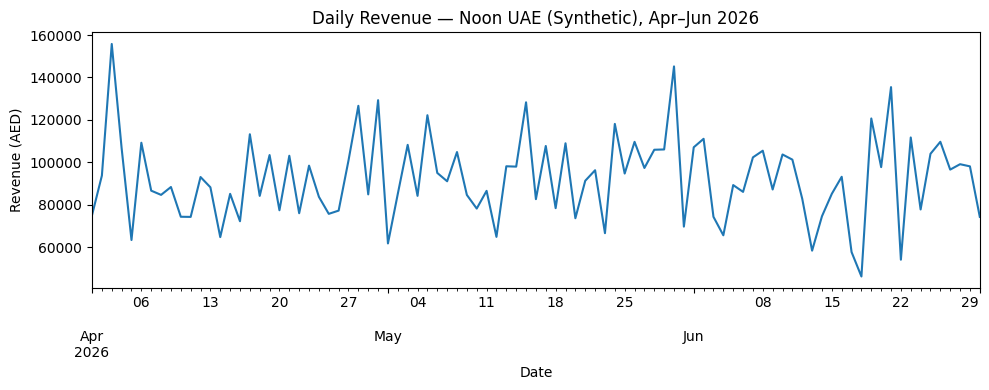

In [7]:
import matplotlib.pyplot as plt

daily = df.copy()
daily["order_date"] = pd.to_datetime(daily["order_date"])
daily_revenue = daily.set_index("order_date").resample("D")["total_amount_aed"].sum()

plt.figure(figsize=(10, 4))
daily_revenue.plot()
plt.title("Daily Revenue — Noon UAE (Synthetic), Apr–Jun 2026")
plt.ylabel("Revenue (AED)")
plt.xlabel("Date")
plt.tight_layout()
plt.show()